# Fake News Detection Using Machine Learning — Final Improved Notebook

This notebook implements a complete, professor-friendly Machine Learning pipeline for Fake News Detection.

Included sections:

1. Dataset loading  
2. Data validation  
3. Missing value and duplicate checks  
4. NLP text cleaning  
5. Feature engineering  
6. Class distribution analysis  
7. Word cloud visualization  
8. Train/test split  
9. TF-IDF vectorization  
10. Multiple ML models  
11. Hyperparameter tuning  
12. Cross-validation  
13. Evaluation metrics  
14. Confusion matrices  
15. ROC-AUC comparison  
16. Feature importance / top terms  
17. Real prediction demo  
18. Final model saving

## 1. Import Required Packages

In [2]:
import os
import re
import string
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not installed. XGBoost model will be skipped.")

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False
    print("wordcloud is not installed. Install using: pip install wordcloud")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Dataset


In [3]:
possible_paths = [
   
    r"C:\Users\ashok\Downloads\generated_fake_news_dataset\full_fake_news_dataset.csv",
    r"C:\Users\ashok\Downloads\generated_fake_news_dataset\fake_news_train_dataset.csv",
    r"C:\Users\ashok\Downloads\generated_fake_news_dataset\fake_news_test_dataset.csv",

    "full_fake_news_dataset.csv",
    "fake_news_train_dataset.csv",
    "fake_news_test_dataset.csv"
]


DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset CSV not found. Please place fakenews_dataset.csv in this folder or update DATA_PATH manually."
    )

df = pd.read_csv(DATA_PATH)
print("Loaded dataset:", DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Loaded dataset: C:\Users\ashok\Downloads\generated_fake_news_dataset\full_fake_news_dataset.csv
Dataset shape: (20771, 12)


,title,text,cleaned_text,label,source,url,publish_date,text_hash,word_count,text_length,capital_ratio,punctuation_count
0,A new Taliban law opens the door to child marr...,A new Taliban law opens the door to child marr...,new taliban law open door child marriage even ...,real,NPR,https://www.npr.org/2026/05/22/nx-s1-5831001/c...,2026-05-22 00:00:00,1413553c78f5e272457e42e3d5468e0c,737,5450,0.024791,142
1,"Oostvaardersplassen, o experimento holandês qu...",O experimento na Holanda que transformou santu...,experimento holanda que transformou santu rio ...,real,BBC,https://www.bbc.com/portuguese/articles/c4g0y9...,NaN,bf60abbe3ef6761e4b4676e458131ecd,2458,17390,0.018033,439
2,Czym jest Aufguss i dlaczego półnagie saunowan...,"Nowy europejski trend zdrowotny: gorące, półna...",nowy europejski trend zdrowotny gor nagie rytu...,real,BBC,https://www.bbc.com/polska/articles/c070942eyyyo,NaN,a63457e28683ee1d7960571eb7e1577c,498,3543,0.030797,83
3,IPL 2026: Vaibhav Sooryavanshi stuns again wit...,Teenage sensation Vaibhav Sooryavanshi produce...,teenage sensation vaibhav sooryavanshi produce...,real,BBC,https://www.bbc.com/sport/cricket/articles/cwy...,NaN,3072d4d7bf02601792a2a3194ba2d924,130,920,0.034139,27
4,Oreo is bringing zero-sugar cookies to the US,Add AP News as your preferred source to see mo...,add news preferred source see story google add...,real,AP,https://apnews.com/article/oreos-zero-sugar-f5...,2025-12-09 20:27:07,c14a0da79608177cf69657740a3c2792,244,1666,0.037537,52


## 3. Data Validation

This step checks whether the required columns exist and standardizes column names.

In [4]:
print("Columns found in dataset:")
print(df.columns.tolist())

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Try to identify text and label columns
if "text" not in df.columns:
    possible_text_cols = [c for c in df.columns if c in ["article", "content", "news", "title", "headline"]]
    if possible_text_cols:
        df = df.rename(columns={possible_text_cols[0]: "text"})
    else:
        raise ValueError("No text column found. Expected a column named 'text'.")

if "label" not in df.columns:
    possible_label_cols = [c for c in df.columns if c in ["target", "class", "category", "labels"]]
    if possible_label_cols:
        df = df.rename(columns={possible_label_cols[0]: "label"})
    else:
        raise ValueError("No label column found. Expected a column named 'label'.")

print("Validated columns:", df.columns.tolist())
print(df[["text", "label"]].head())

Columns found in dataset:
['title', 'text', 'cleaned_text', 'label', 'source', 'url', 'publish_date', 'text_hash', 'word_count', 'text_length', 'capital_ratio', 'punctuation_count']
Validated columns: ['title', 'text', 'cleaned_text', 'label', 'source', 'url', 'publish_date', 'text_hash', 'word_count', 'text_length', 'capital_ratio', 'punctuation_count']
                                                text label
0  A new Taliban law opens the door to child marr...  real
1  O experimento na Holanda que transformou santu...  real
2  Nowy europejski trend zdrowotny: gorące, półna...  real
3  Teenage sensation Vaibhav Sooryavanshi produce...  real
4  Add AP News as your preferred source to see mo...  real


## 4. Missing Value and Duplicate Checks

In [5]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Keep only useful rows
df = df.dropna(subset=["text", "label"]).copy()

# Convert text and label to string
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str).str.strip().str.lower()

# Remove empty texts
df = df[df["text"].str.strip().str.len() > 0].copy()

before_duplicates = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
removed_duplicates = before_duplicates - len(df)

print("\nRows after missing-value cleaning:", len(df))
print("Duplicate rows removed:", removed_duplicates)
print("\nLabel distribution:")
print(df["label"].value_counts())

Missing values before cleaning:
title                   6
text                    0
cleaned_text            0
label                   0
source                  0
url                     0
publish_date         5971
text_hash               0
word_count              0
text_length             0
capital_ratio           0
punctuation_count       0
dtype: int64

Rows after missing-value cleaning: 20771
Duplicate rows removed: 0

Label distribution:
label
fake    14528
real     6243
Name: count, dtype: int64


## 5. NLP Text Cleaning

Cleaning includes:
- lowercase normalization
- URL removal
- HTML tag removal
- punctuation removal
- number removal
- extra whitespace removal
- stopword filtering

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS and len(word) > 2]
    return " ".join(tokens)

df["cleaned_text"] = df["text"].apply(clean_text)

# Remove rows with very short cleaned text
df = df[df["cleaned_text"].str.split().str.len() >= 3].reset_index(drop=True)

print("Dataset shape after NLP cleaning:", df.shape)
df[["text", "cleaned_text", "label"]].head()

Dataset shape after NLP cleaning: (20771, 12)


,text,cleaned_text,label
0,A new Taliban law opens the door to child marr...,new taliban law opens door child marriage togg...,real
1,O experimento na Holanda que transformou santu...,experimento holanda que transformou santu rio ...,real
2,"Nowy europejski trend zdrowotny: gorące, półna...",nowy europejski trend zdrowotny gor nagie rytu...,real
3,Teenage sensation Vaibhav Sooryavanshi produce...,teenage sensation vaibhav sooryavanshi produce...,real
4,Add AP News as your preferred source to see mo...,add news preferred source stories google add n...,real


## 6. Feature Engineering

Additional numerical features are created to support text analysis:
- word count
- character length
- average word length
- punctuation count
- capitalization ratio

In [7]:
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["text"].apply(lambda x: len(str(x)))
df["avg_word_length"] = df["text"].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
)
df["punctuation_count"] = df["text"].apply(lambda x: sum(1 for ch in str(x) if ch in string.punctuation))
df["capital_ratio"] = df["text"].apply(
    lambda x: sum(1 for ch in str(x) if ch.isupper()) / max(len(str(x)), 1)
)

numeric_features = ["word_count", "char_count", "avg_word_length", "punctuation_count", "capital_ratio"]

df[numeric_features + ["label"]].head()

,word_count,char_count,avg_word_length,punctuation_count,capital_ratio,label
0,1353,8269,5.081301,232,0.024791,real
1,3326,21627,5.459110,603,0.018033,real
2,636,4481,6.001572,95,0.030797,real
3,236,1406,4.919492,46,0.034139,real
4,390,2371,5.051282,68,0.037537,real


## 7. Class Distribution Analysis

label
fake    14528
real     6243
Name: count, dtype: int64


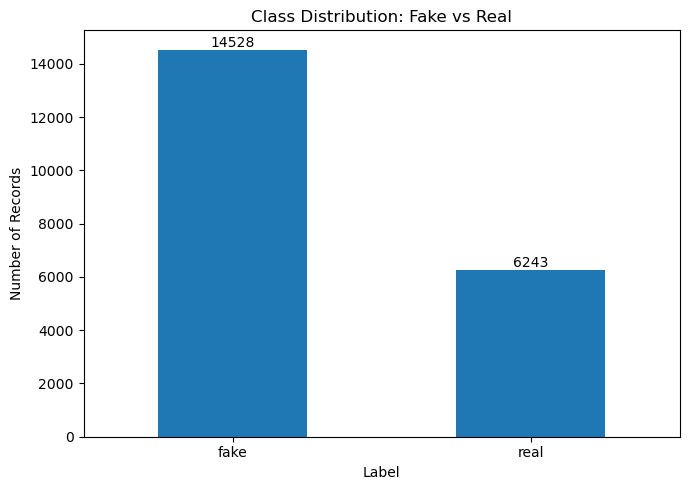

In [8]:
label_counts = df["label"].value_counts()

print(label_counts)

plt.figure(figsize=(7, 5))
label_counts.plot(kind="bar")
plt.title("Class Distribution: Fake vs Real")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

for i, value in enumerate(label_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

Available columns:
Source Distribution:
source
FullFact       11290
BBC             2119
Snopes          2049
AP              1655
Guardian        1557
PolitiFact       924
NPR              912
LeadStories      265
Name: count, dtype: int64

Source Distribution Percentage:
source
FullFact       54.35
BBC            10.20
Snopes          9.86
AP              7.97
Guardian        7.50
PolitiFact      4.45
NPR             4.39
LeadStories     1.28
Name: proportion, dtype: float64


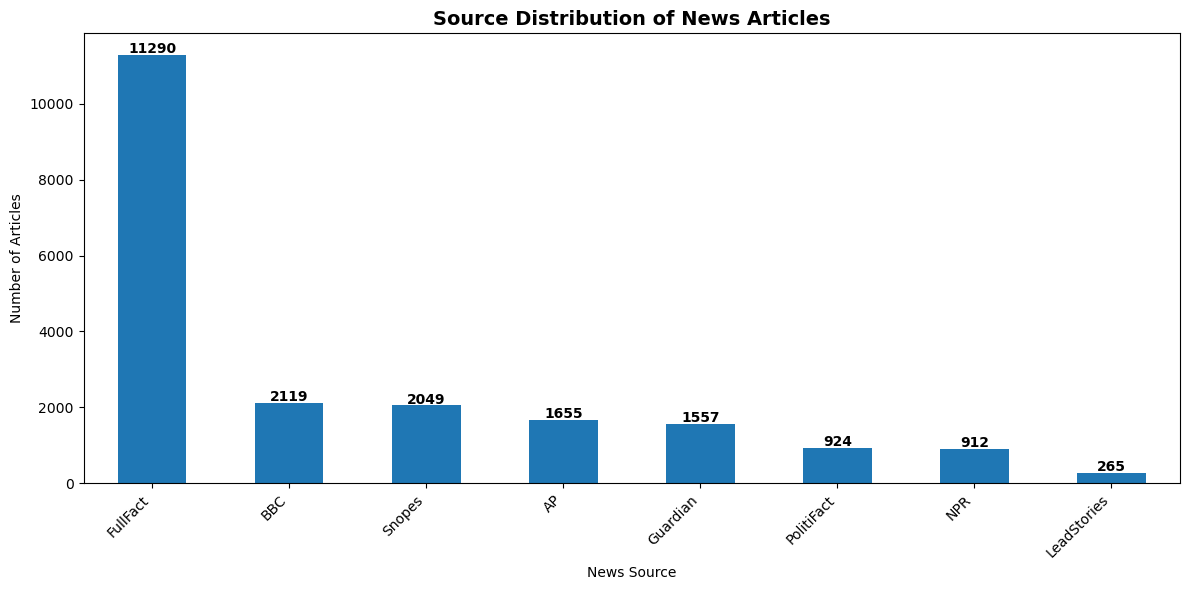

In [9]:
import matplotlib.pyplot as plt

# Check source column
print("Available columns:")

# Source distribution count
source_counts = df['source'].value_counts()

print("Source Distribution:")
print(source_counts)

# Percentage distribution
source_percentages = df['source'].value_counts(normalize=True) * 100

print("\nSource Distribution Percentage:")
print(source_percentages.round(2))

# Bar chart
plt.figure(figsize=(12, 6))
source_counts.plot(kind='bar')

plt.title('Source Distribution of News Articles', fontsize=14, fontweight='bold')
plt.xlabel('News Source')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')

# Add values on bars
for i, value in enumerate(source_counts.values):
    plt.text(i, value + 50, str(value), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

label
fake    14528
real     6243
Name: count, dtype: int64


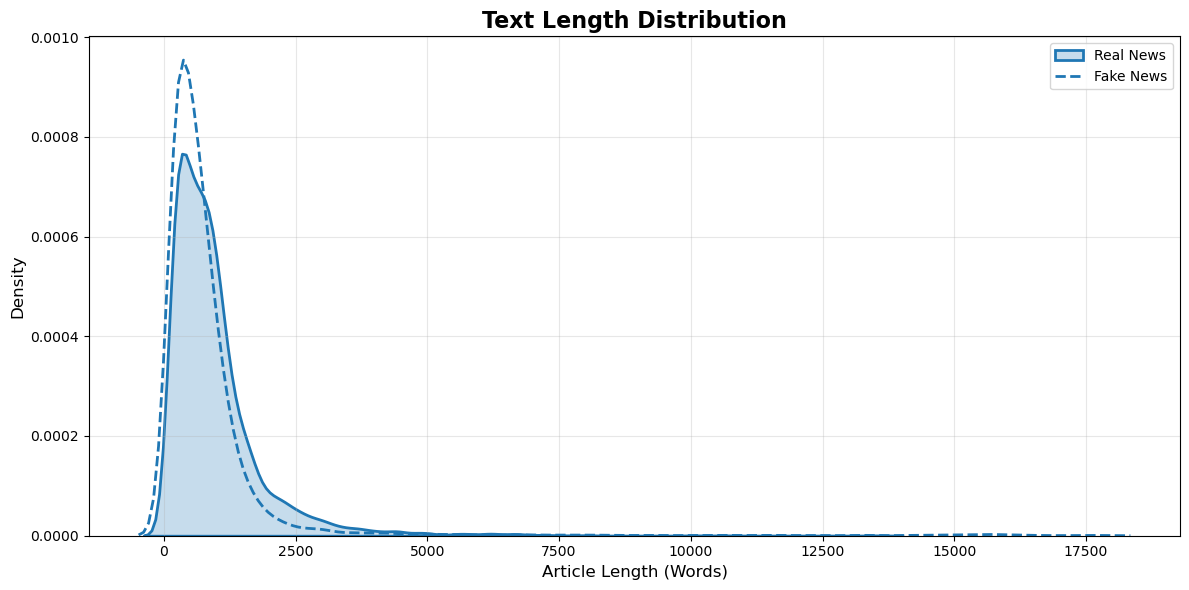

In [13]:
import seaborn as sns
# Create article length feature (word count)
df['article_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Check labels
print(df['label'].value_counts())

plt.figure(figsize=(12,6))

# If labels are strings (Fake/Real)
if df['label'].dtype == 'object':
    
    sns.kdeplot(
        data=df[df['label'].str.lower() == 'real'],
        x='article_length',
        fill=True,
        linewidth=2,
        label='Real News'
    )

    sns.kdeplot(
        data=df[df['label'].str.lower() == 'fake'],
        x='article_length',
        linewidth=2,
        linestyle='--',
        label='Fake News'
    )

# If labels are numeric (0/1)
else:

    sns.kdeplot(
        data=df[df['label'] == 0],
        x='article_length',
        fill=True,
        linewidth=2,
        label='Real News'
    )

    sns.kdeplot(
        data=df[df['label'] == 1],
        x='article_length',
        linewidth=2,
        linestyle='--',
        label='Fake News'
    )

plt.title('Text Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Article Length (Words)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Word Cloud Visualization

Word clouds help visually compare frequent words in fake and real news.

Labels: ['fake', 'real']


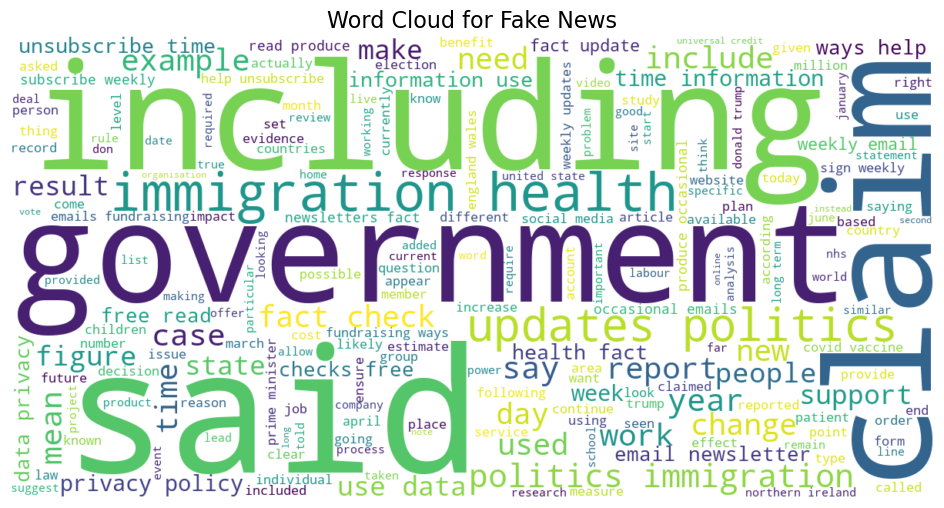

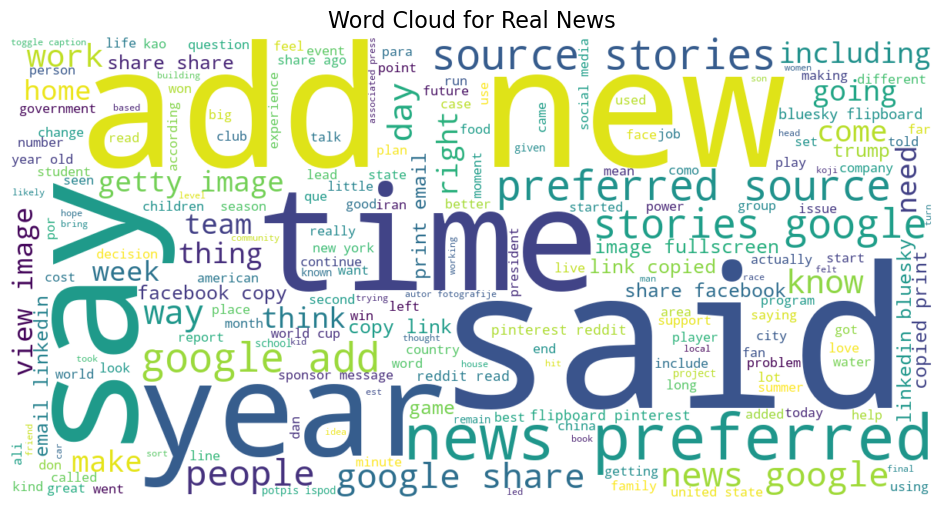

In [13]:
if WORDCLOUD_AVAILABLE:
    unique_labels = sorted(df["label"].unique())
    print("Labels:", unique_labels)

    for label in unique_labels:
        text_data = " ".join(df[df["label"] == label]["cleaned_text"].astype(str))
        if len(text_data.strip()) == 0:
            print(f"No text available for label: {label}")
            continue

        wc = WordCloud(
            width=1200,
            height=600,
            background_color="white",
            max_words=200
        ).generate(text_data)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Word Cloud for {label.title()} News", fontsize=16)
        plt.show()
else:
    print("Skipping WordCloud. Install package using: pip install wordcloud")

## 9. Top 20 Most Common Words by Class

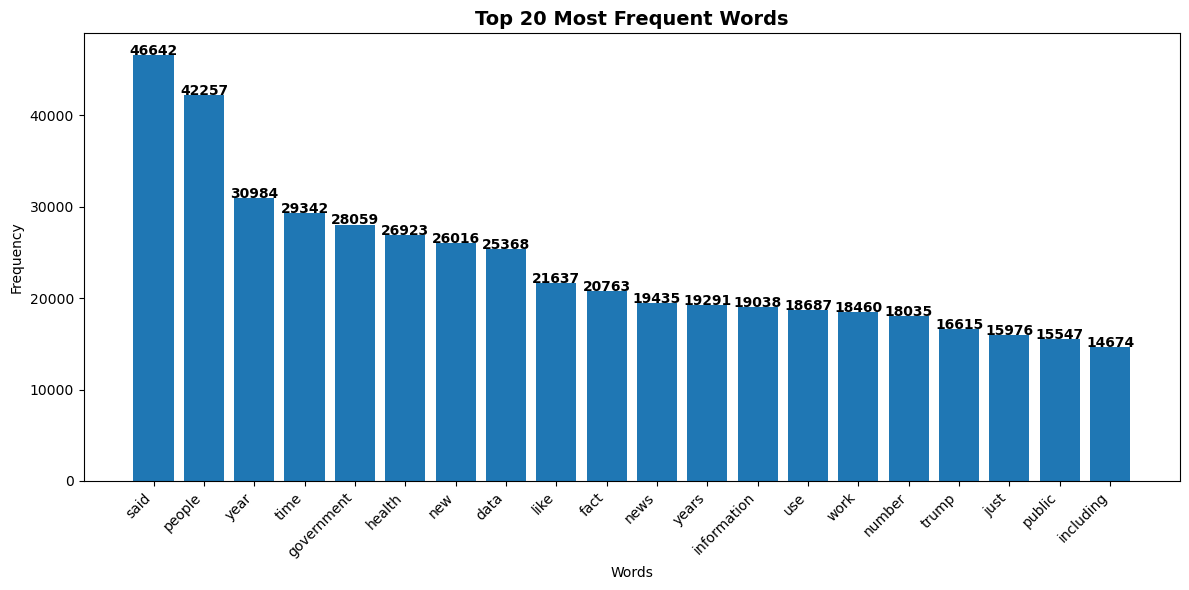

In [14]:
from collections import Counter

# Combine all cleaned text
all_words = " ".join(df["cleaned_text"].astype(str)).split()

# Get top 20 words
top_words = Counter(all_words).most_common(20)

# Convert to DataFrame
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

# Plot
plt.figure(figsize=(12, 6))
plt.bar(top_words_df["word"], top_words_df["count"])

plt.title("Top 20 Most Frequent Words", fontsize=14, fontweight="bold")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

# Add values on bars
for i, v in enumerate(top_words_df["count"]):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

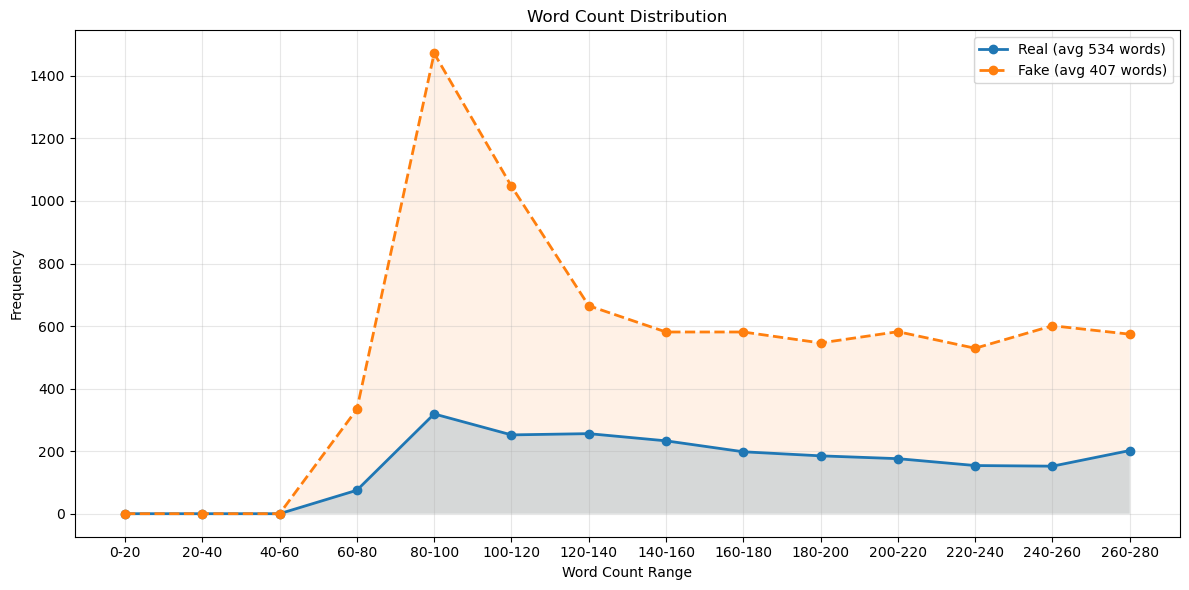

In [15]:
# Calculate word count
df['word_count'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))

# Separate classes
real_df = df[df['label'] == 'real']   # change if using 0/1 labels
fake_df = df[df['label'] == 'fake']

# Create bins
bins = np.arange(0, 281, 20)

# Count frequencies
real_counts, bin_edges = np.histogram(real_df['word_count'], bins=bins)
fake_counts, _ = np.histogram(fake_df['word_count'], bins=bins)

# Bin centers
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    centers,
    real_counts,
    marker='o',
    linewidth=2,
    label=f"Real (avg {real_df['word_count'].mean():.0f} words)"
)

plt.fill_between(
    centers,
    real_counts,
    alpha=0.2
)

plt.plot(
    centers,
    fake_counts,
    marker='o',
    linestyle='--',
    linewidth=2,
    label=f"Fake (avg {fake_df['word_count'].mean():.0f} words)"
)

plt.fill_between(
    centers,
    fake_counts,
    alpha=0.1
)

# X-axis labels like the sample figure
labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(bin_edges)-1)]

plt.xticks(centers, labels, rotation=0)
plt.xlabel("Word Count Range")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Encode Labels

In [15]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

print("Label mapping:")
for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{original} -> {encoded}")

y = df["label_encoded"]
X_text = df["cleaned_text"]

Label mapping:
fake -> 0
real -> 1


## 12. TF-IDF Vectorization

TF-IDF converts cleaned text into numerical features for ML models.

In [21]:
train_df = pd.read_csv(
    r"C:\Users\ashok\Downloads\generated_fake_news_dataset\fake_news_train_dataset.csv"
)

test_df = pd.read_csv(
    r"C:\Users\ashok\Downloads\generated_fake_news_dataset\fake_news_test_dataset.csv"
)

X_train_text = train_df["cleaned_text"]   # or "text" if cleaned_text doesn't exist
X_test_text = test_df["cleaned_text"]

y_train = train_df["label"]
y_test = test_df["label"]

In [22]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,1),
    min_df=15,
    max_df=0.70,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (16617, 5000)
TF-IDF testing shape: (4154, 5000)


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_tfidf,
    y_train
)

## 13. Multiple Machine Learning Models

In [32]:


# Encode labels only for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Label mapping:")
for label, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(label, "->", encoded)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": CalibratedClassifierCV(
        LinearSVC(random_state=RANDOM_STATE, class_weight="balanced")
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

POS_LABEL = "fake"

results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "XGBoost":
        model.fit(X_train_tfidf, y_train_encoded)
        y_pred_encoded = model.predict(X_test_tfidf)
        y_pred = le.inverse_transform(y_pred_encoded.astype(int))
        trained_models[name] = model

        pos_encoded = le.transform([POS_LABEL])[0]

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_tfidf)[:, pos_encoded]
            y_test_binary = (pd.Series(y_test).astype(str) == POS_LABEL).astype(int)
            roc_auc = roc_auc_score(y_test_binary, y_proba)
        else:
            roc_auc = np.nan

    else:
        model.fit(X_train_tfidf, y_train)
        y_pred = model.predict(X_test_tfidf)
        trained_models[name] = model

        if hasattr(model, "predict_proba"):
            class_list = list(model.classes_)
            pos_index = class_list.index(POS_LABEL)

            y_proba = model.predict_proba(X_test_tfidf)[:, pos_index]
            y_test_binary = (pd.Series(y_test).astype(str) == POS_LABEL).astype(int)

            roc_auc = roc_auc_score(y_test_binary, y_proba)
        else:
            roc_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(results_df)

Label mapping:
fake -> 0
real -> 1

Training Logistic Regression...

Training Naive Bayes...

Training Linear SVM...

Training Random Forest...

Training Gradient Boosting...

Training XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,XGBoost,0.932354,0.942347,0.962134,0.952138,0.977905
3,Random Forest,0.919114,0.913155,0.977281,0.944130,0.976882
2,Linear SVM,0.918633,0.935232,0.949398,0.942262,0.970226
4,Gradient Boosting,0.909485,0.914998,0.959725,0.936828,0.965971
0,Logistic Regression,0.913818,0.961580,0.913253,0.936794,0.970619
1,Naive Bayes,0.886375,0.886068,0.961102,0.922061,0.950757


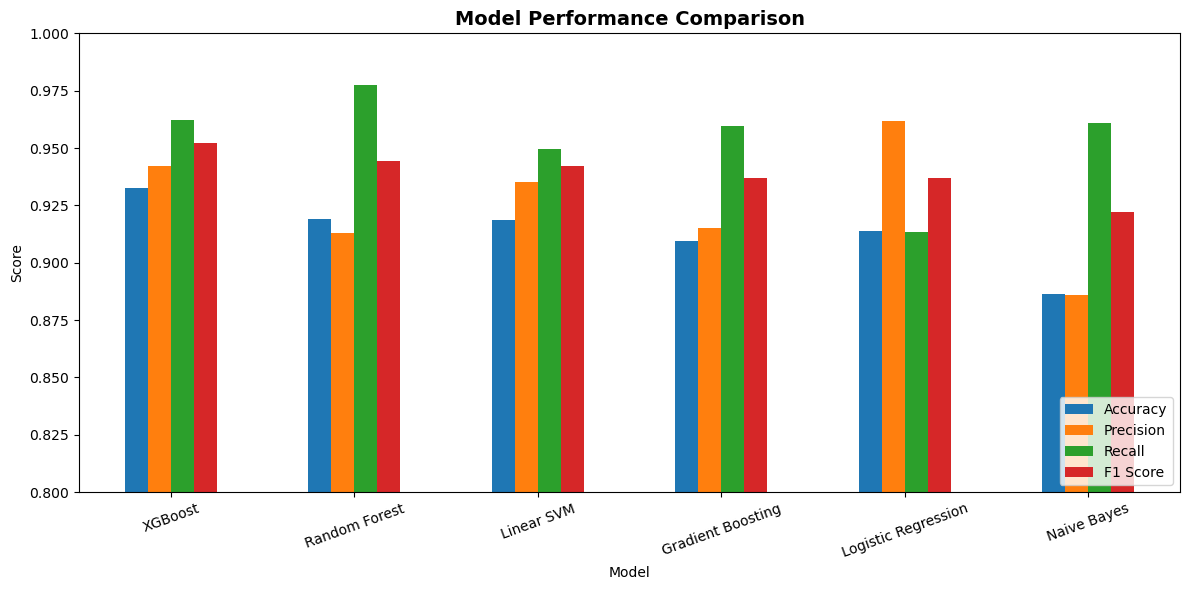

In [46]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

plot_df = results_df.set_index("Model")[metrics]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.80, 1.00)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 14. Hyperparameter Tuning

GridSearchCV is used to tune selected models using cross-validation.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score
import pandas as pd

POS_LABEL = "fake"

# Scorer for string labels
fake_f1_scorer = make_scorer(
    f1_score,
    pos_label=POS_LABEL,
    zero_division=0
)

# Encode labels for XGBoost only
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

fake_encoded = le.transform([POS_LABEL])[0]

fake_f1_scorer_encoded = make_scorer(
    f1_score,
    pos_label=fake_encoded,
    zero_division=0
)

tuning_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["liblinear", "saga"]
        },
        "y": y_train,
        "scorer": fake_f1_scorer
    },

    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {
            "alpha": [0.1, 0.5, 1.0, 2.0],
            "fit_prior": [True, False]
        },
        "y": y_train,
        "scorer": fake_f1_scorer
    },

    "Linear SVM": {
        "model": CalibratedClassifierCV(
            LinearSVC(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                max_iter=5000
            )
        ),
        "params": {
            "estimator__C": [0.01, 0.1, 1, 10]
        },
        "y": y_train,
        "scorer": fake_f1_scorer
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5]
        },
        "y": y_train,
        "scorer": fake_f1_scorer
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            random_state=RANDOM_STATE
        ),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        },
        "y": y_train,
        "scorer": fake_f1_scorer
    }
}

if XGBOOST_AVAILABLE:
    tuning_configs["XGBoost"] = {
        "model": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        },
        "y": y_train_encoded,
        "scorer": fake_f1_scorer_encoded
    }

best_tuned_models = {}
tuning_results = []

for name, config in tuning_configs.items():
    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring=config["scorer"],
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train_tfidf, config["y"])

    best_tuned_models[name] = grid.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Best CV F1 Score": grid.best_score_
    })

    print("Best Parameters:", grid.best_params_)
    print("Best CV F1 Score:", grid.best_score_)

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df)


Tuning Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV F1 Score: 0.9308467638075989

Tuning Naive Bayes...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'alpha': 2.0, 'fit_prior': True}
Best CV F1 Score: 0.9224171030396043

Tuning Linear SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters: {'estimator__C': 0.1}
Best CV F1 Score: 0.9373066512351228

Tuning Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.9413378363279453

Tuning Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV F1 Score: 0.9433815987540525

Tuning XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best 

,Model,Best Parameters,Best CV F1 Score
0,Logistic Regression,"{'C': 10, 'solver': 'liblinear'}",0.930847
1,Naive Bayes,"{'alpha': 2.0, 'fit_prior': True}",0.922417
2,Linear SVM,{'estimator__C': 0.1},0.937307
3,Random Forest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.941338
4,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.943382
5,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.948517


## 15. Cross-Validation

Stratified K-Fold cross-validation gives a more reliable estimate of model performance.

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fake_f1_scorer = make_scorer(
    f1_score,
    pos_label="fake",
    zero_division=0
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

fake_encoded = le.transform(["fake"])[0]

fake_f1_scorer_encoded = make_scorer(
    f1_score,
    pos_label=fake_encoded,
    zero_division=0
)

cv_results = []

for name, model in trained_models.items():
    print(f"Cross-validating {name}...")

    if name == "XGBoost":
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train_encoded,
            cv=cv,
            scoring=fake_f1_scorer_encoded,
            n_jobs=-1
        )
    else:
        scores = cross_val_score(
            model,
            X_train_tfidf,
            y_train,
            cv=cv,
            scoring=fake_f1_scorer,
            n_jobs=-1
        )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values(
    by="Mean CV F1",
    ascending=False
)

display(cv_df)

Cross-validating Logistic Regression...
Cross-validating Naive Bayes...
Cross-validating Linear SVM...
Cross-validating Random Forest...
Cross-validating Gradient Boosting...
Cross-validating XGBoost...


,Model,Mean CV F1,CV Std
5,XGBoost,0.948667,0.001519
3,Random Forest,0.941243,0.001673
2,Linear SVM,0.937118,0.001758
4,Gradient Boosting,0.936665,0.002598
0,Logistic Regression,0.931228,0.004811
1,Naive Bayes,0.922035,0.002361


## 16. Evaluation Metrics for Tuned Models

In [38]:
tuned_results = []

POS_LABEL = "fake"

for name, model in best_tuned_models.items():
    print(f"Evaluating {name}...")

    # XGBoost was trained with encoded labels
    if name == "XGBoost":
        y_pred_encoded = model.predict(X_test_tfidf)
        y_pred = le.inverse_transform(y_pred_encoded)

        if hasattr(model, "predict_proba"):
            fake_index = le.transform([POS_LABEL])[0]
            y_proba = model.predict_proba(X_test_tfidf)[:, fake_index]
            y_test_binary = (y_test == POS_LABEL).astype(int)
            roc_auc = roc_auc_score(y_test_binary, y_proba)
        else:
            roc_auc = np.nan

    else:
        y_pred = model.predict(X_test_tfidf)

        if hasattr(model, "predict_proba"):
            classes = list(model.classes_)
            fake_index = classes.index(POS_LABEL)
            y_proba = model.predict_proba(X_test_tfidf)[:, fake_index]
            y_test_binary = (y_test == POS_LABEL).astype(int)
            roc_auc = roc_auc_score(y_test_binary, y_proba)
        else:
            roc_auc = np.nan

    tuned_results.append({
        "Model": name + " (Tuned)",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "Recall": recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0),
        "ROC-AUC": roc_auc
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    by="F1 Score",
    ascending=False
)

display(tuned_results_df)

Evaluating Logistic Regression...
Evaluating Naive Bayes...
Evaluating Linear SVM...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,XGBoost (Tuned),0.932354,0.942347,0.962134,0.952138,0.977905
4,Gradient Boosting (Tuned),0.923929,0.931932,0.961446,0.946459,0.975820
3,Random Forest (Tuned),0.921521,0.918261,0.974527,0.945558,0.976182
2,Linear SVM (Tuned),0.918633,0.934937,0.949742,0.942281,0.970557
0,Logistic Regression (Tuned),0.910688,0.959724,0.910499,0.934464,0.970301
1,Naive Bayes (Tuned),0.886375,0.886068,0.961102,0.922061,0.950819


## 17. Confusion Matrices

Best model selected: XGBoost (Tuned)


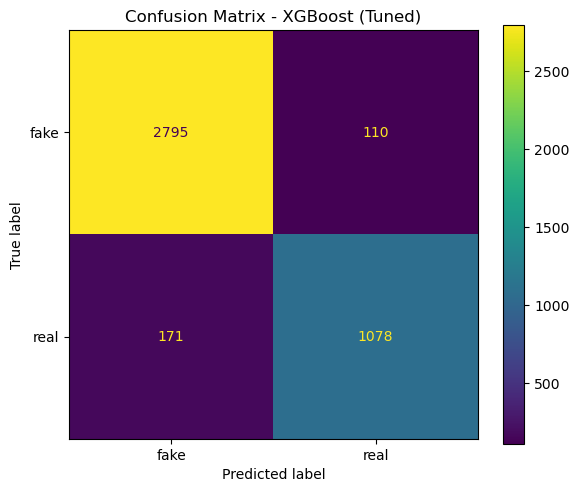

              precision    recall  f1-score   support

        fake       0.94      0.96      0.95      2905
        real       0.91      0.86      0.88      1249

    accuracy                           0.93      4154
   macro avg       0.92      0.91      0.92      4154
weighted avg       0.93      0.93      0.93      4154



In [40]:
# Select best model by tuned F1 if available, otherwise baseline F1

if len(tuned_results_df) > 0:
    best_name_display = tuned_results_df.iloc[0]["Model"]
    best_key = best_name_display.replace(" (Tuned)", "")
    best_model = best_tuned_models[best_key]
else:
    best_name_display = results_df.iloc[0]["Model"]
    best_key = best_name_display
    best_model = trained_models[best_key]

print("Best model selected:", best_name_display)

# Predict
if best_key == "XGBoost":
    y_pred_encoded = best_model.predict(X_test_tfidf)
    y_pred_best = le.inverse_transform(y_pred_encoded)
else:
    y_pred_best = best_model.predict(X_test_tfidf)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=["fake", "real"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["fake", "real"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="viridis", values_format="d", ax=ax)
ax.set_title(f"Confusion Matrix - {best_name_display}")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_test,
        y_pred_best,
        labels=["fake", "real"],
        target_names=["fake", "real"],
        zero_division=0
    )
)

## ROC-AUC Comparison

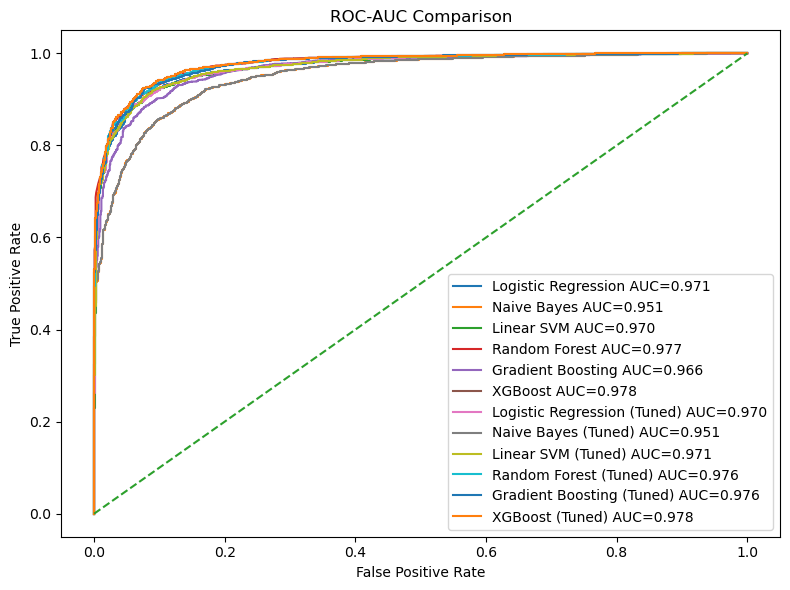

,Model,ROC-AUC
5,XGBoost,0.977905
11,XGBoost (Tuned),0.977905
3,Random Forest,0.976882
9,Random Forest (Tuned),0.976182
10,Gradient Boosting (Tuned),0.975820
0,Logistic Regression,0.970619
8,Linear SVM (Tuned),0.970557
6,Logistic Regression (Tuned),0.970301
2,Linear SVM,0.970226
4,Gradient Boosting,0.965971


In [42]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

POS_LABEL = "fake"

plt.figure(figsize=(8, 6))

roc_table = []

all_models_for_roc = {}
all_models_for_roc.update(trained_models)
all_models_for_roc.update({
    name + " (Tuned)": model 
    for name, model in best_tuned_models.items()
})

# Convert y_test to binary for ROC
y_test_binary = (y_test == POS_LABEL).astype(int)

for name, model in all_models_for_roc.items():
    if hasattr(model, "predict_proba"):

        # XGBoost tuned model was trained with encoded labels
        if "XGBoost" in name and "(Tuned)" in name:
            fake_index = le.transform([POS_LABEL])[0]
            y_proba = model.predict_proba(X_test_tfidf)[:, fake_index]

        else:
            classes = list(model.classes_)

            if POS_LABEL in classes:
                fake_index = classes.index(POS_LABEL)
                y_proba = model.predict_proba(X_test_tfidf)[:, fake_index]
            else:
                # for encoded models
                fake_index = le.transform([POS_LABEL])[0]
                y_proba = model.predict_proba(X_test_tfidf)[:, fake_index]

        auc = roc_auc_score(y_test_binary, y_proba)
        fpr, tpr, _ = roc_curve(y_test_binary, y_proba)

        plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

        roc_table.append({
            "Model": name,
            "ROC-AUC": auc
        })

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC-AUC Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

roc_df = pd.DataFrame(roc_table).sort_values(
    by="ROC-AUC",
    ascending=False
)

display(roc_df)

##  Real Prediction Demo

This section demonstrates how the trained model predicts unseen news text.

In [48]:
def predict_news(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    pred = model.predict(vectorized)[0]
    label = label_encoder.inverse_transform([pred])[0]

    confidence = None
    if hasattr(model, "predict_proba"):
        confidence = model.predict_proba(vectorized).max()

    return label, confidence

demo_examples = [
    "Government officials released a verified report today with updated economic data and public health statistics.",
    "Shocking secret video proves that celebrities are controlling the election results online."
]

for text in demo_examples:
    label, confidence = predict_news(text)
    print("\nNews text:", text)
    print("Predicted label:", label)
    if confidence is not None:
        print("Confidence:", round(confidence, 4))


News text: Government officials released a verified report today with updated economic data and public health statistics.
Predicted label: fake
Confidence: 0.7886

News text: Shocking secret video proves that celebrities are controlling the election results online.
Predicted label: fake
Confidence: 0.6004


## 21. Final Model Saving

In [45]:
MODEL_DIR = "model_results"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "best_fake_news_ml_model.pkl")
vectorizer_path = os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl")
label_encoder_path = os.path.join(MODEL_DIR, "label_encoder.pkl")
results_path = os.path.join(MODEL_DIR, "model_results_summary.csv")

joblib.dump(best_model, model_path)
joblib.dump(tfidf, vectorizer_path)
joblib.dump(label_encoder, label_encoder_path)

final_results = pd.concat([results_df, tuned_results_df], ignore_index=True)
final_results.to_csv(results_path, index=False)

print("Saved best model to:", model_path)
print("Saved TF-IDF vectorizer to:", vectorizer_path)
print("Saved label encoder to:", label_encoder_path)
print("Saved results summary to:", results_path)

Saved best model to: model_results\best_fake_news_ml_model.pkl
Saved TF-IDF vectorizer to: model_results\tfidf_vectorizer.pkl
Saved label encoder to: model_results\label_encoder.pkl
Saved results summary to: model_results\model_results_summary.csv
